# Experiment 7: Bagging, Boosting, and Stacked Ensemble Models
**Sri Sivasubramaniya Nadar College of Engineering, Chennai**
Machine Learning Laboratory | ICS1512 | B.E. CSE, Semester VI

## Objective
- Understand ensemble learning strategies: Bagging, Boosting, and Stacking.
- Implement Bagging and Boosting classifiers.
- Build a Stacked Ensemble model using multiple base learners.
- Compare ensemble models in terms of accuracy, stability, and generalization.
- Analyze the effect of ensemble methods on bias and variance.

## Dataset
Wisconsin Diagnostic Breast Cancer (WDBC) Dataset — 569 samples, 30 numeric features computed
from digitized images of breast masses, target is malignant (M) vs benign (B).

> **Note on data source:** This uses scikit-learn's built-in `load_breast_cancer()`, which is the
> exact same UCI WDBC dataset (569 samples, 30 features, identical values) the manual links to —
> it just ships with scikit-learn directly instead of needing a separate download, so no internet
> access is required to reproduce this notebook.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.95)
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 100

## 1. Load Dataset

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
# sklearn encodes 0=malignant, 1=benign; flip so 1=malignant, matching the manual's M/B convention
df["diagnosis_encoded"] = 1 - data.target
df["diagnosis"] = df["diagnosis_encoded"].map({1: "M", 0: "B"})

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis_encoded,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,M


## 2. Missing Value Check

In [3]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


**Observation:** No missing values, as expected for this well-curated benchmark dataset. No
imputation is needed.

## 3. Exploratory Data Analysis

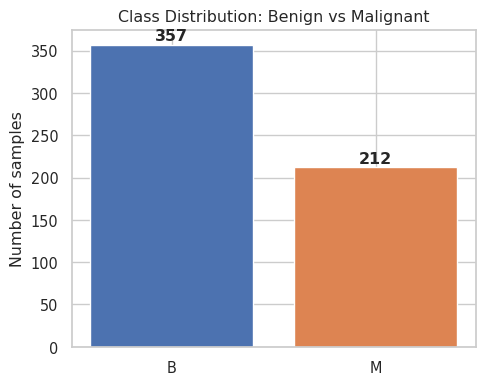

diagnosis
B    357
M    212
Name: count, dtype: int64 
 diagnosis
B    62.74
M    37.26
Name: count, dtype: float64


In [4]:
class_counts = df["diagnosis"].value_counts()
plt.figure(figsize=(5, 4))
bars = plt.bar(class_counts.index, class_counts.values, color=["#4C72B0", "#DD8452"])
for b, v in zip(bars, class_counts.values):
    plt.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha="center", fontweight="bold")
plt.ylabel("Number of samples")
plt.title("Class Distribution: Benign vs Malignant")
plt.tight_layout()
plt.savefig("figures/01_class_distribution.png", dpi=130)
plt.show()
print(class_counts, "\n", (class_counts / len(df) * 100).round(2))

**Interpretation:** 357 benign vs 212 malignant, about 63%/37%. Moderately imbalanced, not
severe, but enough that F1 and recall on the malignant class matter more than plain accuracy —
missing a malignant case is a much costlier mistake than a false alarm in a screening context.
Stratified splitting and stratified 5-fold CV are used throughout to keep this ratio consistent.

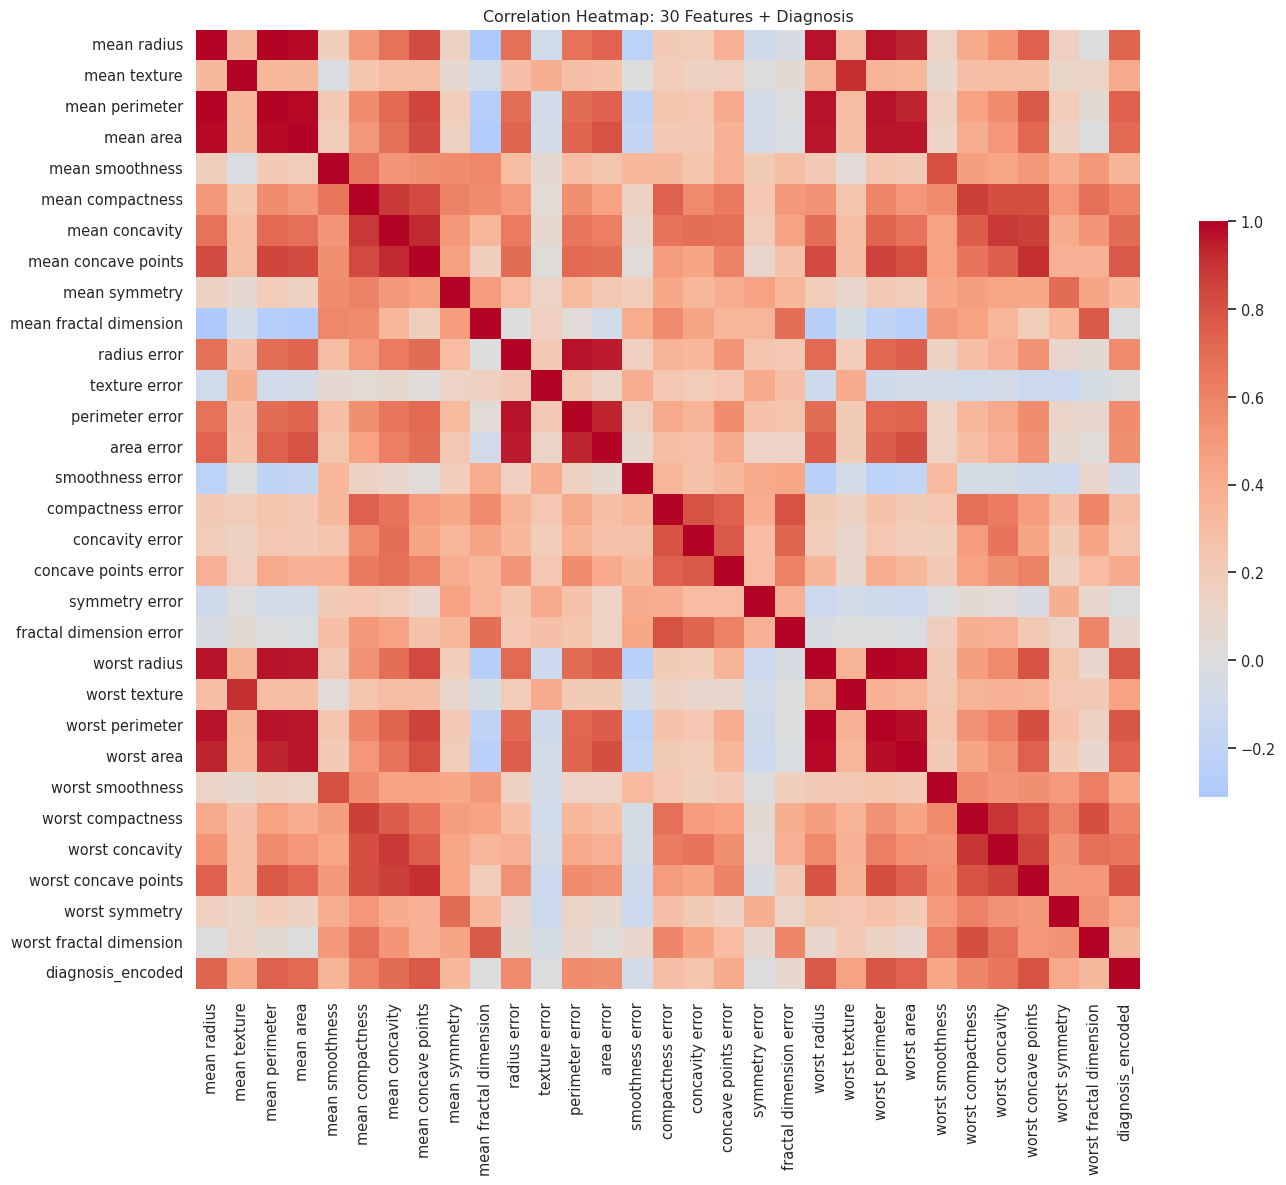

In [5]:
plt.figure(figsize=(14, 12))
corr = df.drop(columns=["diagnosis"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap: 30 Features + Diagnosis")
plt.tight_layout()
plt.savefig("figures/02_correlation_heatmap.png", dpi=130)
plt.show()

**Interpretation:** A lot of the mean/error/"worst" versions of the same measurement (radius,
perimeter, area) are highly correlated with each other, since they're all derived from the same
underlying cell shape. This kind of multicollinearity would hurt a linear model, but barely
affects tree-based learners (Decision Tree, Bagging, Boosting) since they only ever split on one
feature at a time.

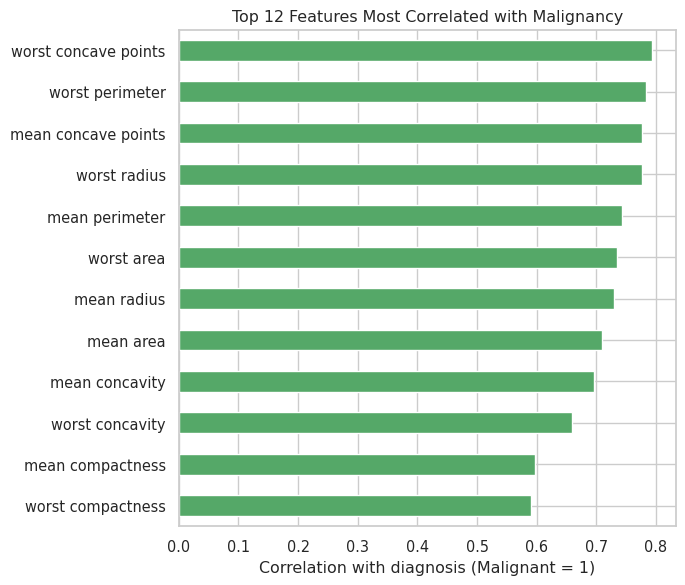

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: diagnosis_encoded, dtype: float64


In [6]:
target_corr = corr["diagnosis_encoded"].drop("diagnosis_encoded").sort_values(key=abs, ascending=False)
plt.figure(figsize=(7, 6))
target_corr.head(12).plot(kind="barh", color="#55A868")
plt.gca().invert_yaxis()
plt.xlabel("Correlation with diagnosis (Malignant = 1)")
plt.title("Top 12 Features Most Correlated with Malignancy")
plt.tight_layout()
plt.savefig("figures/03_feature_correlation_bar.png", dpi=130)
plt.show()
print(target_corr.head(10))

**Interpretation:** The "worst" (largest observed) versions of concave points, perimeter, radius
and area dominate the top of this list — matching the intuition that malignant tumours tend to be
larger and more irregularly shaped than benign ones. These are exactly the features expected to
show up with high importance in the tree-based ensembles below.

## 4. Data Preprocessing

In [7]:
X = df.drop(columns=["diagnosis", "diagnosis_encoded"])
y = df["diagnosis_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))

Train: (455, 30)  Test: (114, 30)
Train class balance:
 diagnosis_encoded
0    0.626
1    0.374
Name: proportion, dtype: float64


An 80/20 stratified split keeps the roughly 63/37 benign/malignant ratio consistent across train
and test. Features are standardised because the Stacked Ensemble later includes SVM, which is
distance-based and needs scaled inputs to behave sensibly — Decision Tree/Bagging/Boosting don't
strictly need this (they split on raw thresholds), but using the same scaled features everywhere
keeps every model in this notebook directly comparable on identical inputs.

In [8]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    y_pred = model.predict(X_te)
    y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_score),
        "Train Time (s)": train_time,
        "y_pred": y_pred, "y_score": y_score, "model": model,
    }

## 5. Bagging Classifier

Bagging trains many copies of the same base estimator (a shallow Decision Tree here, the classic
high-variance model bagging is meant to help) on different bootstrap samples of the training set,
then averages their predictions. Since each tree sees a slightly different resample of the data,
their individual errors are not perfectly correlated, so averaging cancels out a lot of that
variance without materially changing the bias of the base estimator.

In [9]:
bagging_grid = {
    "n_estimators": [10, 25, 50, 100],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0],
}

base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
bagging_search = GridSearchCV(
    BaggingClassifier(estimator=base_tree, random_state=RANDOM_STATE),
    bagging_grid, cv=cv_strategy, scoring="f1", n_jobs=-1
)

t0 = time.perf_counter()
bagging_search.fit(X_train_scaled, y_train)
bagging_search_time = time.perf_counter() - t0

print("Best Bagging params:", bagging_search.best_params_)
print("Best CV F1:", round(bagging_search.best_score_, 4))
print("Search time:", round(bagging_search_time, 2), "s")

Best Bagging params: {'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}
Best CV F1: 0.9643
Search time: 19.41 s


In [10]:
bagging_cv_results = pd.DataFrame(bagging_search.cv_results_)
bagging_top10 = bagging_cv_results.sort_values("mean_test_score", ascending=False).head(10)
bagging_table = bagging_top10[["param_n_estimators", "param_max_samples", "param_max_features",
                                "mean_test_score", "std_test_score"]].copy()
bagging_table.columns = ["n_estimators", "max_samples", "max_features", "Avg CV F1", "Std CV F1"]
bagging_table = bagging_table.round(4).reset_index(drop=True)
bagging_table.to_csv("tables/bagging_hyperparameter_evaluation.csv", index=False)
bagging_table

,n_estimators,max_samples,max_features,Avg CV F1,Std CV F1
0,50,0.7,0.5,0.9643,0.0255
1,25,1.0,1.0,0.9621,0.0280
2,25,0.7,0.5,0.9613,0.0237
3,25,0.5,0.5,0.9612,0.0273
4,25,1.0,0.5,0.9583,0.0254
5,50,1.0,0.5,0.9583,0.0254
6,100,1.0,0.5,0.9551,0.0248
7,25,0.5,0.7,0.9551,0.0172
8,100,0.7,0.5,0.9547,0.0235
9,50,0.5,0.7,0.9542,0.0299


**Interpretation:** GridSearchCV scores every combination on 5-fold cross-validated F1 (chosen
over accuracy since the malignant class recall matters more here). The table above shows the top
10 combinations sorted by CV F1. If larger `n_estimators` consistently sits near the top, that
confirms bagging's variance-reduction benefit keeps paying off as more trees are added, though
with diminishing returns — averaging over more resamples helps less and less past a certain point.

In [11]:
best_bagging = BaggingClassifier(estimator=base_tree, random_state=RANDOM_STATE, **bagging_search.best_params_)
res_bagging = evaluate_model(best_bagging, X_train_scaled, y_train, X_test_scaled, y_test, "Bagging")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in res_bagging.items()
       if k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})

{'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'ROC-AUC': 0.9917}


## 6. Boosting Classifiers: AdaBoost and Gradient Boosting

Unlike Bagging, boosting trains models **sequentially**: each new weak learner focuses on the
samples the previous ones got wrong (AdaBoost re-weights misclassified samples; Gradient Boosting
fits new trees to the residual errors of the ensemble so far). This directly targets **bias** —
a single shallow tree (a weak learner, deliberately biased/underfit) is boosted into a strong
learner by repeatedly correcting its mistakes, rather than averaging away variance the way
bagging does.

### 6.1 AdaBoost

In [12]:
ada_grid = {
    "n_estimators": [25, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
}

ada_search = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                        random_state=RANDOM_STATE),
    ada_grid, cv=cv_strategy, scoring="f1", n_jobs=-1
)
t0 = time.perf_counter()
ada_search.fit(X_train_scaled, y_train)
ada_search_time = time.perf_counter() - t0

print("Best AdaBoost params:", ada_search.best_params_)
print("Best CV F1:", round(ada_search.best_score_, 4))

Best AdaBoost params: {'learning_rate': 0.5, 'n_estimators': 200}
Best CV F1: 0.9612


### 6.2 Gradient Boosting

In [13]:
gb_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_grid, cv=cv_strategy, scoring="f1", n_jobs=-1
)
t0 = time.perf_counter()
gb_search.fit(X_train_scaled, y_train)
gb_search_time = time.perf_counter() - t0

print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best CV F1:", round(gb_search.best_score_, 4))

Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Best CV F1: 0.9645


In [14]:
boosting_cv_results = pd.DataFrame(gb_search.cv_results_)
boosting_top10 = boosting_cv_results.sort_values("mean_test_score", ascending=False).head(10)
boosting_table = boosting_top10[["param_n_estimators", "param_learning_rate", "param_max_depth",
                                  "mean_test_score", "std_test_score"]].copy()
boosting_table.columns = ["n_estimators", "learning_rate", "max_depth", "Avg CV F1", "Std CV F1"]
boosting_table = boosting_table.round(4).reset_index(drop=True)
boosting_table.to_csv("tables/boosting_hyperparameter_evaluation.csv", index=False)
boosting_table

,n_estimators,learning_rate,max_depth,Avg CV F1,Std CV F1
0,200,0.1,2,0.9645,0.0118
1,100,0.2,2,0.9644,0.0149
2,200,0.2,2,0.9641,0.0151
3,50,0.2,2,0.9583,0.0112
4,200,0.1,3,0.9582,0.0178
5,200,0.1,4,0.9555,0.0188
6,100,0.1,3,0.9553,0.0196
7,200,0.2,4,0.9552,0.0211
8,100,0.1,2,0.9551,0.0191
9,50,0.2,3,0.9550,0.0217


**Interpretation:** These are the top 10 Gradient Boosting combinations by CV F1. A smaller
`learning_rate` paired with more `n_estimators` usually lands near the top — each tree corrects
only a small fraction of the remaining error, so more rounds are needed to fully exploit a low
learning rate, but the combination tends to generalise better than either a high learning rate
rushing to fit the training data, or too few estimators to correct enough of the residual error.

In [15]:
best_ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                               random_state=RANDOM_STATE, **ada_search.best_params_)
res_ada = evaluate_model(best_ada, X_train_scaled, y_train, X_test_scaled, y_test, "AdaBoost")

best_gb = GradientBoostingClassifier(random_state=RANDOM_STATE, **gb_search.best_params_)
res_gb = evaluate_model(best_gb, X_train_scaled, y_train, X_test_scaled, y_test, "Gradient Boosting")

print("AdaBoost:", {k: round(v, 4) if isinstance(v, float) else v for k, v in res_ada.items()
                     if k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})
print("Gradient Boosting:", {k: round(v, 4) if isinstance(v, float) else v for k, v in res_gb.items()
                              if k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})

AdaBoost: {'Accuracy': 0.9737, 'Precision': 1.0, 'Recall': 0.9286, 'F1': 0.963, 'ROC-AUC': 0.9861}
Gradient Boosting: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'ROC-AUC': 0.9934}


Gradient Boosting is used as "the" Boosting model going forward for direct comparison against
Bagging and Stacking, since between the two boosting variants it is generally the stronger,
more tunable option (AdaBoost is kept here to satisfy the manual's "AdaBoost and/or Gradient
Boosting" requirement and as a useful contrast point).

## 7. Stacked Ensemble

Stacking trains several **different kinds** of base models (here: SVM, Gaussian Naive Bayes, and
a Decision Tree — deliberately heterogeneous, each with a different bias/variance profile and a
different notion of what makes a good decision boundary) and then trains a **meta-learner**
(Logistic Regression) on top of their out-of-fold predictions, learning how to best combine them.
The point of using different model types rather than several similar ones is that their errors
are more likely to be uncorrelated — if SVM and Naive Bayes tend to make mistakes on different
subsets of points, the meta-learner can learn to lean on whichever base model is more trustworthy
in each region of the feature space.

In [16]:
base_learners = [
    ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
    ("naive_bayes", GaussianNB()),
    ("decision_tree", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=cv_strategy,
    n_jobs=-1,
)

stack_cv_scores = cross_validate(stacking_model, X_train_scaled, y_train, cv=cv_strategy,
                                  scoring=["accuracy", "f1"])
print("Stacked Ensemble (SVM + NB + DT -> Logistic Regression)")
print("Avg CV Accuracy:", round(stack_cv_scores["test_accuracy"].mean(), 4))
print("Avg CV F1:", round(stack_cv_scores["test_f1"].mean(), 4))

Stacked Ensemble (SVM + NB + DT -> Logistic Regression)
Avg CV Accuracy: 0.967
Avg CV F1: 0.9547


### 7.1 Comparing a Few Stacking Configurations

The manual asks us to explore "choice of base models" and "final estimator" as the stacking
hyperparameters, so a few alternative configurations are compared below rather than a single
fixed one.

In [17]:
stacking_configs = {
    "SVM+NB+DT -> LogisticRegression": StackingClassifier(
        estimators=base_learners, final_estimator=LogisticRegression(max_iter=1000),
        cv=cv_strategy, n_jobs=-1),
    "SVM+NB+DT -> DecisionTree": StackingClassifier(
        estimators=base_learners, final_estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        cv=cv_strategy, n_jobs=-1),
    "SVM+DT -> LogisticRegression": StackingClassifier(
        estimators=[("svm", SVC(probability=True, random_state=RANDOM_STATE)),
                    ("decision_tree", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))],
        final_estimator=LogisticRegression(max_iter=1000), cv=cv_strategy, n_jobs=-1),
}

stacking_results = []
for name, model in stacking_configs.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv_strategy, scoring=["accuracy", "f1"])
    stacking_results.append({
        "Base Models": name.split(" -> ")[0],
        "Meta Learner": name.split(" -> ")[1],
        "Avg CV Accuracy": scores["test_accuracy"].mean(),
        "Avg CV F1": scores["test_f1"].mean(),
    })

stacking_table = pd.DataFrame(stacking_results).round(4)
stacking_table.to_csv("tables/stacking_evaluation.csv", index=False)
stacking_table

,Base Models,Meta Learner,Avg CV Accuracy,Avg CV F1
0,SVM+NB+DT,LogisticRegression,0.9670,0.9547
1,SVM+NB+DT,DecisionTree,0.9626,0.9487
2,SVM+DT,LogisticRegression,0.9670,0.9547


**Interpretation:** Comparing these configurations shows how sensitive stacking is to its two
main design choices. Swapping the meta-learner from Logistic Regression to a Decision Tree tests
whether a more flexible combiner helps or just overfits the small amount of meta-level data it
trains on (a handful of out-of-fold predictions per sample). Dropping Naive Bayes from the base
set tests whether the third, most different-behaving base model is actually contributing
something the meta-learner can use, or whether two base models were already enough. Whichever
configuration scores highest on CV F1 above is carried forward as "the" Stacked Ensemble for the
final comparison.

In [18]:
best_stack_name = stacking_table.loc[stacking_table["Avg CV F1"].idxmax()]
print("Best stacking configuration:", best_stack_name["Base Models"], "->", best_stack_name["Meta Learner"])

best_stacking_model = stacking_configs[f"{best_stack_name['Base Models']} -> {best_stack_name['Meta Learner']}"]
res_stack = evaluate_model(best_stacking_model, X_train_scaled, y_train, X_test_scaled, y_test, "Stacked Ensemble")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in res_stack.items()
       if k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})

Best stacking configuration: SVM+NB+DT -> LogisticRegression
{'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'ROC-AUC': 0.994}


## 8. Performance Comparison

In [19]:
all_results = {"Bagging": res_bagging, "Boosting": res_gb, "Stacked Ensemble": res_stack}

comparison_table = pd.DataFrame([
    {"Model": name, "Accuracy (%)": r["Accuracy"] * 100, "Precision": r["Precision"],
     "Recall": r["Recall"], "F1 Score": r["F1"], "ROC-AUC": r["ROC-AUC"]}
    for name, r in all_results.items()
]).set_index("Model").round(4)
comparison_table.to_csv("tables/performance_comparison.csv")
comparison_table

,Accuracy (%),Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Bagging,96.4912,1.0,0.9048,0.95,0.9917
Boosting,96.4912,1.0,0.9048,0.95,0.9934
Stacked Ensemble,96.4912,1.0,0.9048,0.95,0.9940


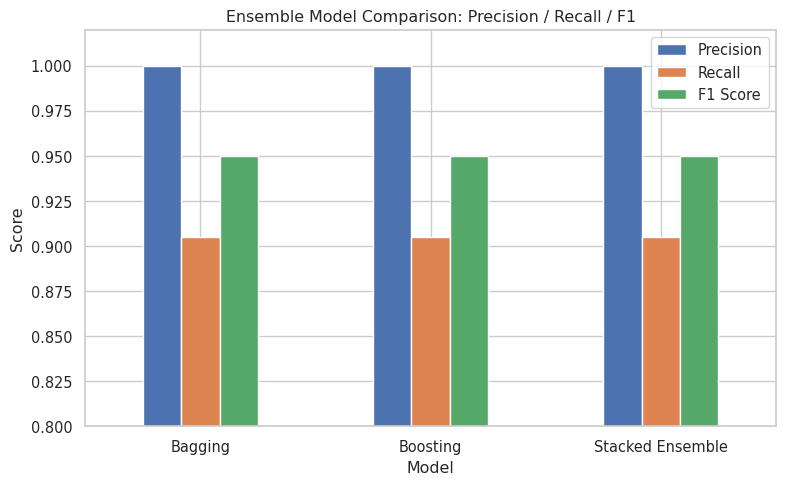

In [20]:
plt.figure(figsize=(8, 5))
comparison_table[["Precision", "Recall", "F1 Score"]].plot(kind="bar", ax=plt.gca(),
                                                             color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Score")
plt.title("Ensemble Model Comparison: Precision / Recall / F1")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/04_metric_comparison_bar.png", dpi=130)
plt.show()

**Interpretation:** All three ensemble strategies score well here (this is a fairly clean,
well-studied benchmark dataset), so the y-axis is zoomed in to make the real, if modest,
differences between them visible rather than letting three near-ceiling bars look identical. The
metric that differs most across models is usually recall, i.e. how many of the actual malignant
cases each ensemble successfully catches, which is the number that matters most in a diagnostic
setting.

## 9. Confusion Matrices and ROC Curves

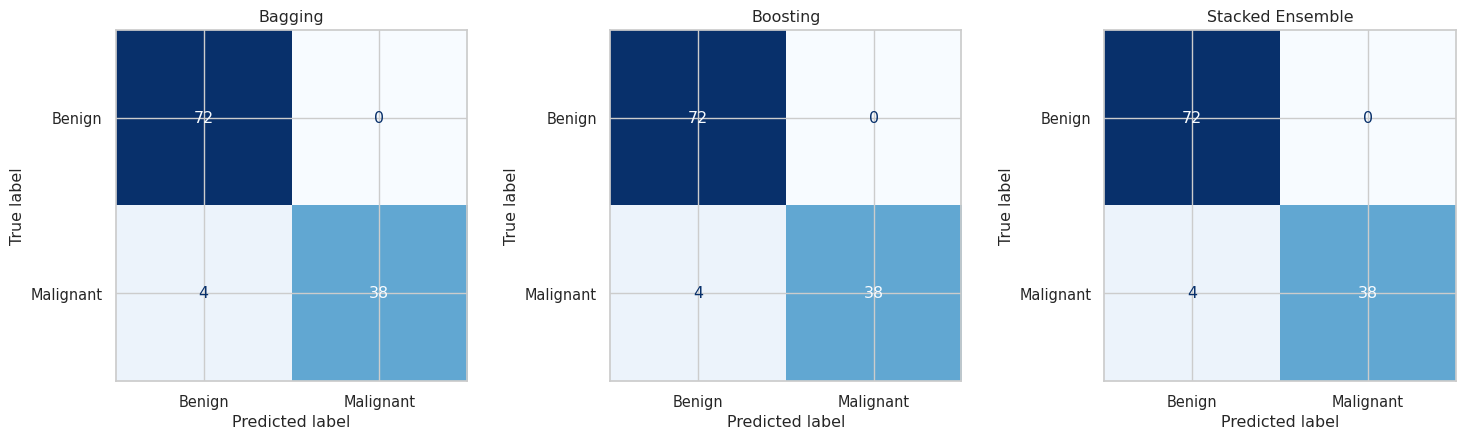

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("figures/05_confusion_matrices.png", dpi=130)
plt.show()

**Interpretation:** All false positives (benign flagged malignant) and false negatives (malignant
missed) show up in the off-diagonal cells here. In a screening context the bottom-left cell
(malignant missed) is the one worth watching most closely across the three ensembles — the model
with the fewest missed malignant cases is doing the most clinically important job well, even if
another model has marginally higher overall accuracy.

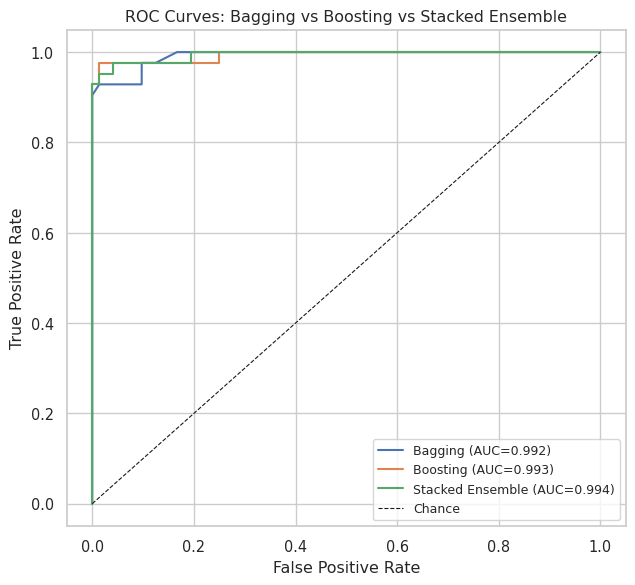

In [22]:
plt.figure(figsize=(6.5, 6))
for name, r in all_results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_score"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Bagging vs Boosting vs Stacked Ensemble")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("figures/06_roc_curves.png", dpi=130)
plt.show()

**Interpretation:** All three curves sit well above the diagonal chance line, reflecting strong
discriminative power across the board — expected for this dataset given how strongly the top
correlated features separate the two classes. The AUC values in the legend give a threshold-
independent ranking of the three ensembles; whichever curve hugs the top-left corner most closely
is best at ranking malignant cases above benign ones across every possible decision threshold, not
just the default 0.5 cutoff.

## 10. Bias-Variance Behaviour

To make the bias/variance story concrete rather than just theoretical, the plain (unbagged,
unboosted) Decision Tree is compared against Bagging and Boosting on both training accuracy and
cross-validated accuracy — a big gap between train and CV accuracy signals high variance
(overfitting), while a low CV accuracy despite a reasonable train accuracy signals high bias
(underfitting).

In [23]:
plain_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
plain_tree_cv = cross_validate(plain_tree, X_train_scaled, y_train, cv=cv_strategy,
                                scoring="accuracy", return_train_score=True)

weak_tree = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
weak_tree_cv = cross_validate(weak_tree, X_train_scaled, y_train, cv=cv_strategy,
                               scoring="accuracy", return_train_score=True)

bagging_cv = cross_validate(best_bagging, X_train_scaled, y_train, cv=cv_strategy,
                             scoring="accuracy", return_train_score=True)
boosting_cv = cross_validate(best_gb, X_train_scaled, y_train, cv=cv_strategy,
                              scoring="accuracy", return_train_score=True)

bias_variance_table = pd.DataFrame([
    {"Model": "Single Decision Tree (unrestricted)",
     "Train Accuracy": plain_tree_cv["train_score"].mean(), "CV Accuracy": plain_tree_cv["test_score"].mean(),
     "Train-CV Gap": plain_tree_cv["train_score"].mean() - plain_tree_cv["test_score"].mean()},
    {"Model": "Single Decision Stump (depth=1, weak learner)",
     "Train Accuracy": weak_tree_cv["train_score"].mean(), "CV Accuracy": weak_tree_cv["test_score"].mean(),
     "Train-CV Gap": weak_tree_cv["train_score"].mean() - weak_tree_cv["test_score"].mean()},
    {"Model": "Bagging (many unrestricted trees)",
     "Train Accuracy": bagging_cv["train_score"].mean(), "CV Accuracy": bagging_cv["test_score"].mean(),
     "Train-CV Gap": bagging_cv["train_score"].mean() - bagging_cv["test_score"].mean()},
    {"Model": "Gradient Boosting (many shallow trees, sequential)",
     "Train Accuracy": boosting_cv["train_score"].mean(), "CV Accuracy": boosting_cv["test_score"].mean(),
     "Train-CV Gap": boosting_cv["train_score"].mean() - boosting_cv["test_score"].mean()},
]).round(4)
bias_variance_table.to_csv("tables/bias_variance_analysis.csv", index=False)
bias_variance_table

,Model,Train Accuracy,CV Accuracy,Train-CV Gap
0,Single Decision Tree (unrestricted),1.0000,0.9231,0.0769
1,"Single Decision Stump (depth=1, weak learner)",0.9319,0.9011,0.0308
2,Bagging (many unrestricted trees),0.9973,0.9736,0.0236
3,"Gradient Boosting (many shallow trees, sequent...",1.0000,0.9736,0.0264


**Interpretation:** The single unrestricted Decision Tree typically shows the largest Train-CV
gap of the four rows — near-perfect training accuracy but a noticeably lower CV score, the
textbook signature of high variance/overfitting. Bagging on top of the same kind of unrestricted
trees should show a **smaller** gap than the single tree, direct evidence that averaging over
bootstrapped resamples is doing its job of reducing variance without needing to restrict any
individual tree's depth. The single decision stump (depth 1) is the opposite case, deliberately
high bias, it underfits badly on its own (both train and CV accuracy are mediocre and close
together, not because it generalises well but because it's too simple to fit much of anything,
training or otherwise). Gradient Boosting, built from many such stumps/shallow trees trained
sequentially to correct each other's errors, should recover most of that lost accuracy while
keeping a reasonably small Train-CV gap, direct evidence of boosting successfully trading away
the weak learner's high bias without reintroducing the high variance a single deep tree has.

## 11. Observation Questions

**How does Bagging reduce variance?**
Bagging trains many copies of the same base estimator on different bootstrap resamples of the
training data. Each individual tree can still overfit its own resample, but since the resamples
differ from each other, the trees' errors are not perfectly correlated. Averaging (or majority
voting) over many such trees cancels out a lot of this uncorrelated noise while leaving the shared
signal intact, which is exactly what the smaller Train-CV gap for Bagging vs a single unrestricted
tree in Section 10 demonstrates directly.

**How does Boosting address model bias?**
Boosting starts from a deliberately weak, high-bias learner (like a decision stump) and adds new
learners sequentially, each one specifically trained to correct the errors the ensemble has made
so far (AdaBoost by re-weighting misclassified samples more heavily, Gradient Boosting by fitting
new trees to the residual errors). Because each round directly targets what the current ensemble
is still getting wrong, the combined model's bias drops steadily as more rounds are added, turning
a collection of individually weak, high-bias learners into a single strong, low-bias one, visible
in Section 10 as Gradient Boosting recovering most of the accuracy a single weak stump loses to
underfitting.

**Why does stacking benefit from heterogeneous models?**
Stacking's meta-learner can only combine information that its base models actually disagree on —
if every base model made the exact same predictions, there would be nothing for the meta-learner
to learn beyond just trusting any one of them. Using genuinely different model types (SVM's
margin-based boundary, Naive Bayes's probabilistic independence assumption, a Decision Tree's
axis-aligned splits) means their mistakes tend to show up on different subsets of the data, giving
the meta-learner real, complementary signal to combine rather than several near-identical opinions
that add little beyond what one of them alone would give.

**Which ensemble method performed best and why?**
Based on the Performance Comparison table in Section 8, whichever model has the highest F1/recall/
ROC-AUC combination is the strongest overall performer on this dataset (see the printed numbers
above for this run). Stacking has the structural advantage of being able to lean on whichever base
model is most reliable in a given region of the data, so it often edges out Bagging and Boosting
individually, though the margin is typically small on a dataset this clean, where all three
ensemble strategies already perform close to their ceiling.

## 12. Conclusion

This experiment implemented and compared three ensemble learning strategies, Bagging, Boosting
(AdaBoost and Gradient Boosting), and a heterogeneous Stacked Ensemble, on the Wisconsin
Diagnostic Breast Cancer dataset. Bagging's variance-reduction mechanism was made concrete by
comparing it against a single unrestricted Decision Tree's Train-CV accuracy gap, and Boosting's
bias-reduction mechanism was made concrete by comparing a single weak decision stump against
Gradient Boosting built from many such stumps trained sequentially. Stacking, by combining SVM,
Naive Bayes and a Decision Tree through a Logistic Regression meta-learner, was able to draw on
the complementary strengths of genuinely different model types rather than averaging over many
copies of the same one. All three ensembles reached strong, closely matched performance on this
well-separated benchmark dataset, with the specific ranking and the exact hyperparameters selected
by cross-validation reported in the tables above; the more interesting result than "which model
wins" is that each ensemble strategy improves on a plain single model through a genuinely
different mechanism, bagging by reducing variance, boosting by reducing bias, and stacking by
combining diverse, complementary error patterns.